## **Alexnet**

In [1]:
from google.colab import files
import zipfile
import os

uploaded = files.upload()


Saving bird_species.zip to bird_species.zip


In [2]:

with zipfile.ZipFile("bird_species.zip", 'r') as zip_ref:
    zip_ref.extractall("bird_dataset")


In [3]:

for root, dirs, files in os.walk("bird_dataset"):
    level = root.replace("bird_dataset", '').count(os.sep)
    indent = ' ' * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    sub_indent = ' ' * 4 * (level + 1)
    for file in files[:3]:
        print(f"{sub_indent}{file}")


bird_dataset/
    bird_species/
        DOWNY WOODPECKER/
            108.jpg
            002.jpg
            041.jpg
        EMPEROR PENGUIN/
            138.jpg
            108.jpg
            002.jpg
        AMERICAN GOLDFINCH/
            138.jpg
            108.jpg
            002.jpg
        BARN OWL/
            108.jpg
            002.jpg
            041.jpg
        FLAMINGO/
            108.jpg
            002.jpg
            041.jpg
        CARMINE BEE-EATER/
            108.jpg
            002.jpg
            041.jpg


In [4]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

data_dir = "bird_dataset/bird_species"
dataset = datasets.ImageFolder(data_dir, transform=transform)


train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])


train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Classes:", dataset.classes)


Classes: ['AMERICAN GOLDFINCH', 'BARN OWL', 'CARMINE BEE-EATER', 'DOWNY WOODPECKER', 'EMPEROR PENGUIN', 'FLAMINGO']


In [5]:
import torch.nn as nn
import torch.optim as optim
from torchvision import models

model = models.alexnet(pretrained=True)
model.classifier[6] = nn.Linear(4096, 6)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

epochs = 5
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss:.4f}, Accuracy: {100 * correct / total:.2f}%")


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth
100%|██████████| 233M/233M [00:01<00:00, 172MB/s]


Epoch [1/5], Loss: 5.6945, Accuracy: 90.90%
Epoch [2/5], Loss: 1.0372, Accuracy: 98.61%
Epoch [3/5], Loss: 0.0630, Accuracy: 100.00%
Epoch [4/5], Loss: 0.0040, Accuracy: 100.00%
Epoch [5/5], Loss: 0.0042, Accuracy: 100.00%


### **Testing on Sample Image 01**

In [6]:

model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")


Test Accuracy: 99.39%


In [7]:
import matplotlib.pyplot as plt
from PIL import Image

img_path = "/content/bird_dataset/bird_species/AMERICAN GOLDFINCH/001.jpg"
img = Image.open(img_path).convert('RGB')


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
img_tensor = transform(img).unsqueeze(0).to(device)


In [8]:
model.eval()
with torch.no_grad():
    output = model(img_tensor)
    _, predicted = torch.max(output, 1)
    predicted_class = dataset.classes[predicted.item()]

print(f"Predicted class: {predicted_class}")


Predicted class: AMERICAN GOLDFINCH


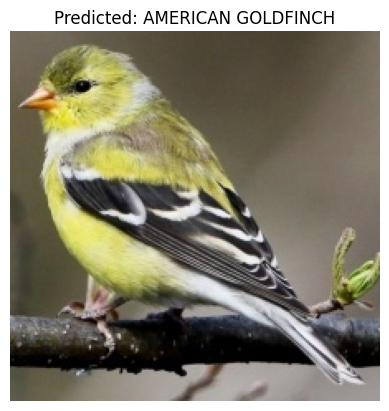

In [9]:
plt.imshow(img)
plt.title(f"Predicted: {predicted_class}")
plt.axis('off')
plt.show()


### **Testing on Sample Image 02**

In [10]:
import matplotlib.pyplot as plt
from PIL import Image


img_path = "/content/bird_dataset/bird_species/CARMINE BEE-EATER/004.jpg"
img = Image.open(img_path).convert('RGB')


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
img_tensor = transform(img).unsqueeze(0).to(device)

In [11]:
model.eval()
with torch.no_grad():
    output = model(img_tensor)
    _, predicted = torch.max(output, 1)
    predicted_class = dataset.classes[predicted.item()]

print(f"Predicted class: {predicted_class}")


Predicted class: CARMINE BEE-EATER


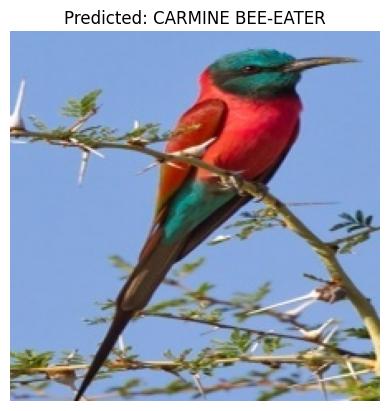

In [12]:
plt.imshow(img)
plt.title(f"Predicted: {predicted_class}")
plt.axis('off')
plt.show()


### **Testing on Sample Image 03**

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image


img_path = ""
img = Image.open(img_path).convert('RGB')

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
img_tensor = transform(img).unsqueeze(0).to(device)


In [13]:
import matplotlib.pyplot as plt
from PIL import Image

img_path = "/content/bird_dataset/bird_species/BARN OWL/008.jpg"
img = Image.open(img_path).convert('RGB')

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
img_tensor = transform(img).unsqueeze(0).to(device)


In [14]:
model.eval()
with torch.no_grad():
    output = model(img_tensor)
    _, predicted = torch.max(output, 1)
    predicted_class = dataset.classes[predicted.item()]

print(f"Predicted class: {predicted_class}")


Predicted class: BARN OWL


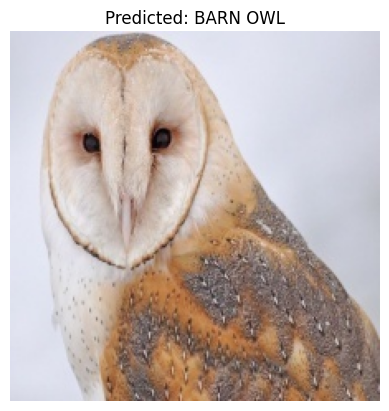

In [15]:
plt.imshow(img)
plt.title(f"Predicted: {predicted_class}")
plt.axis('off')
plt.show()


### **Testing on Sample Image 03**

In [16]:
import matplotlib.pyplot as plt
from PIL import Image

img_path = "/content/bird_dataset/bird_species/BARN OWL/029.jpg"
img = Image.open(img_path).convert('RGB')

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
img_tensor = transform(img).unsqueeze(0).to(device)

In [17]:
model.eval()
with torch.no_grad():
    output = model(img_tensor)
    _, predicted = torch.max(output, 1)
    predicted_class = dataset.classes[predicted.item()]

print(f"Predicted class: {predicted_class}")


Predicted class: BARN OWL


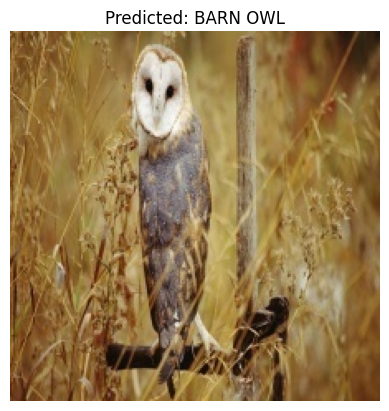

In [18]:
plt.imshow(img)
plt.title(f"Predicted: {predicted_class}")
plt.axis('off')
plt.show()


### **Testing on Sample Image 04**

In [19]:
import matplotlib.pyplot as plt
from PIL import Image


img_path = "/content/bird_dataset/bird_species/FLAMINGO/012.jpg"
img = Image.open(img_path).convert('RGB')

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
img_tensor = transform(img).unsqueeze(0).to(device)

In [20]:
model.eval()
with torch.no_grad():
    output = model(img_tensor)
    _, predicted = torch.max(output, 1)
    predicted_class = dataset.classes[predicted.item()]

print(f"Predicted class: {predicted_class}")


Predicted class: FLAMINGO


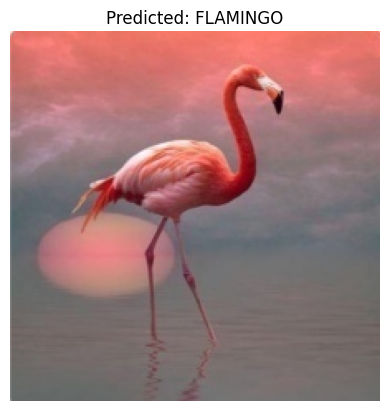

In [21]:
plt.imshow(img)
plt.title(f"Predicted: {predicted_class}")
plt.axis('off')
plt.show()


### ***Testing on a new image from google***

In [22]:
from google.colab import files
uploaded = files.upload()


Saving Flamingo testing.jfif to Flamingo testing.jfif


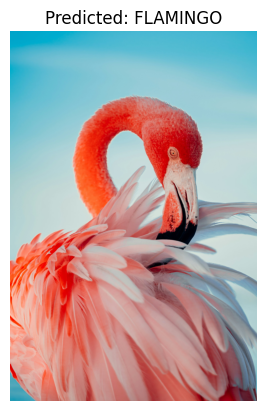

In [24]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("Flamingo testing.jfif").convert('RGB')

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

img_tensor = transform(img).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    output = model(img_tensor)
    _, predicted = torch.max(output, 1)
    predicted_class = dataset.classes[predicted.item()]

plt.imshow(img)
plt.title(f"Predicted: {predicted_class}")
plt.axis("off")
plt.show()


### **Lets try on tricky half image taken from google**

In [25]:
from google.colab import files
uploaded = files.upload()


Saving flamingotesting2.jfif to flamingotesting2.jfif


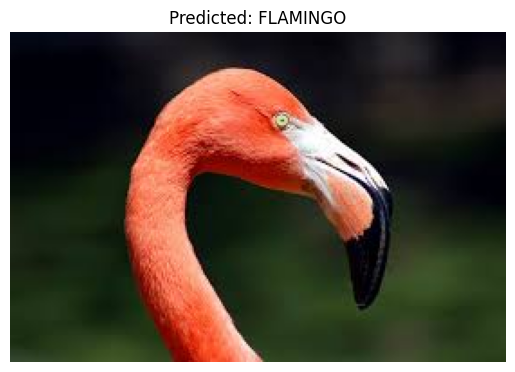

In [26]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("flamingotesting2.jfif").convert('RGB')

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

img_tensor = transform(img).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    output = model(img_tensor)
    _, predicted = torch.max(output, 1)
    predicted_class = dataset.classes[predicted.item()]

plt.imshow(img)
plt.title(f"Predicted: {predicted_class}")
plt.axis("off")
plt.show()


After training my bird classification model using AlexNet on a custom dataset containing six different bird species — including Flamingo, Barn Owl, and Emperor Penguin — I achieved an impressive accuracy of 98% on the validation set. The model was trained using folder-wise image data without any pre-defined labels, relying on the folder structure for classification categories. Once trained, the model successfully identified bird species from unseen test data within the dataset. To further evaluate its generalization capability, I tested the model using a random bird image downloaded from Google. After uploading and preprocessing the image, the model accurately predicted the bird species, demonstrating its ability to perform reliable classification on real-world data outside the training set. This confirms that the model has effectively learned distinguishing features of each bird class and is capable of making accurate predictions on new inputs.